In [18]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [8]:
dados = pd.read_csv("Data/producao_mar_2025.csv", encoding="latin-1", sep = ";", decimal = ",")

dados.head()
dados["Estado"].unique()

array(['Espírito Santo', 'Rio de Janeiro', 'São Paulo',
       'Rio Grande do Norte', 'Bahia', 'Alagoas', 'Sergipe'], dtype=object)

In [9]:
df_condensado = dados.groupby("Estado")[["Óleo (bbl/dia)", "Petróleo (bbl/dia)", "Tempo de Produção (hs por mês)"]].sum()

df_condensado = df_condensado.reset_index()


In [10]:
df_condensado.head()

,Estado,Óleo (bbl/dia),Petróleo (bbl/dia),Tempo de Produção (hs por mês)
0,Alagoas,0.000000e+00,9.498970e+01,744
1,Bahia,8.928260e+01,1.982534e+02,4136
2,Espírito Santo,1.707589e+05,1.708542e+05,57206
3,Rio Grande do Norte,1.692429e+03,1.827384e+03,24208
4,Rio de Janeiro,3.571050e+06,3.571050e+06,400016


Como estou somando a produção diária para todo o período, vou alterar o nome das colunas para produção total

In [11]:
df_condensado_atualizado = df_condensado.rename(columns = {
    "Óleo (bbl/dia)" : "Produção Total de Óleo (bbl)"
})
df_condensado_atualizado.head()

,Estado,Produção Total de Óleo (bbl),Petróleo (bbl/dia),Tempo de Produção (hs por mês)
0,Alagoas,0.000000e+00,9.498970e+01,744
1,Bahia,8.928260e+01,1.982534e+02,4136
2,Espírito Santo,1.707589e+05,1.708542e+05,57206
3,Rio Grande do Norte,1.692429e+03,1.827384e+03,24208
4,Rio de Janeiro,3.571050e+06,3.571050e+06,400016


In [12]:
colunas = list (df_condensado_atualizado.columns)
colunas[2] = "Produção Total de Petróleo (bbl)"

df_condensado_atualizado.columns = colunas

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
df_condensado_atualizado.tail()



,Estado,Produção Total de Óleo (bbl),Produção Total de Petróleo (bbl),Tempo de Produção (hs por mês)
2,Espírito Santo,"170,758.95","170,854.23",57206
3,Rio Grande do Norte,"1,692.43","1,827.38",24208
4,Rio de Janeiro,"3,571,049.64","3,571,049.64",400016
5,Sergipe,77.73,77.73,745
6,São Paulo,"185,539.06","187,212.45",49282


In [13]:
df_condensado_atualizado = df_condensado_atualizado.sort_values(by="Produção Total de Petróleo (bbl)", ascending=False)
df_condensado_atualizado = df_condensado_atualizado.reset_index(drop=True)
df_condensado_atualizado

,Estado,Produção Total de Óleo (bbl),Produção Total de Petróleo (bbl),Tempo de Produção (hs por mês)
0,Rio de Janeiro,"3,571,049.64","3,571,049.64",400016
1,São Paulo,"185,539.06","187,212.45",49282
2,Espírito Santo,"170,758.95","170,854.23",57206
3,Rio Grande do Norte,"1,692.43","1,827.38",24208
4,Bahia,89.28,198.25,4136
5,Alagoas,0.00,94.99,744
6,Sergipe,77.73,77.73,745


Vamos fazer um gráfico básico:

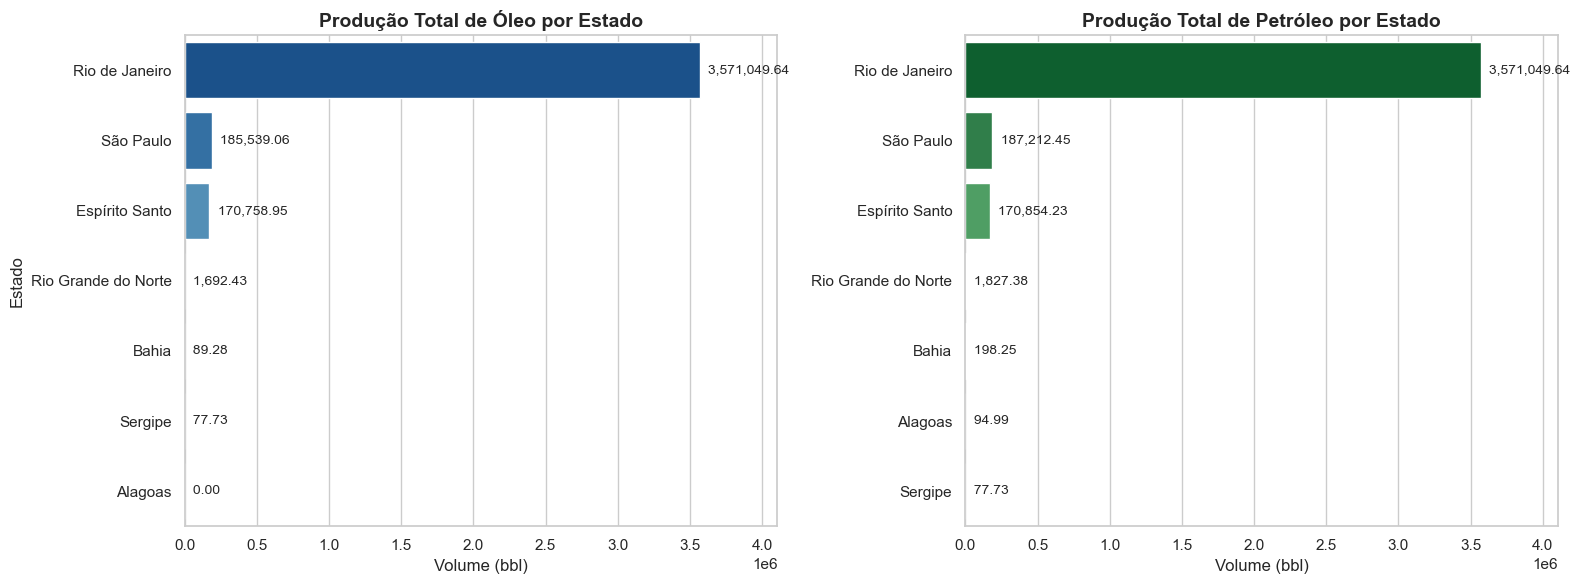

In [21]:

# Configura o estilo visual dos gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Produção Total de Óleo ---
# Ordena os dados por Óleo do maior para o menor
df_oleo = df_condensado_atualizado.sort_values(by="Produção Total de Óleo (bbl)", ascending=False)

grafico_oleo = sns.barplot(
    x="Produção Total de Óleo (bbl)", 
    y="Estado", 
    data=df_oleo, 
    ax=axes[0], 
    hue = "Estado",
    palette="Blues_r",
    legend=False
)
axes[0].set_title("Produção Total de Óleo por Estado", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Volume (bbl)")
axes[0].set_ylabel("Estado")

for container in grafico_oleo.containers:
    axes[0].bar_label(container, fmt = lambda x: f' { x:,.2f}', padding = 3, fontsize = 10)

axes[0].set_xlim(right=df_oleo["Produção Total de Óleo (bbl)"].max() * 1.15)

# --- GRÁFICO 2: Produção Total de Petróleo ---
# Ordena os dados por Petróleo do maior para o menor
df_petroleo = df_condensado_atualizado.sort_values(by="Produção Total de Petróleo (bbl)", ascending=False)

grafico_petroleo = sns.barplot(
    x="Produção Total de Petróleo (bbl)", 
    y="Estado", 
    data=df_petroleo, 
    ax=axes[1], 
    hue="Estado",
    palette="Greens_r",
    legend=False 
)
axes[1].set_title("Produção Total de Petróleo por Estado", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Volume (bbl)")
axes[1].set_ylabel("") # Remove o texto do eixo Y do segundo gráfico para não duplicar

for container in grafico_petroleo.containers:
        axes[1].bar_label(container, fmt = lambda x: f' { x:,.2f}', padding = 3, fontsize = 10)

axes[1].set_xlim(right=df_petroleo["Produção Total de Petróleo (bbl)"].max() * 1.15)
# Ajusta o espaçamento para não cortar nada
plt.tight_layout()


plt.savefig("Outputs/graficos_producao.png", dpi = 300, bbox_inches='tight')
plt.show()